# Experiment Conclusion

**Objective**: Summarise the full modelling experiment — compare all models, identify the champion, and document the final evaluation results.

**Experiment recap**:
- **Dataset**: `factory_cleaned.csv` — 3,789 Singapore factory transactions (2023–2025), train/test split 80/20 (random_state=42)
- **Three model families tested**: Ridge Regression, Random Forest, XGBoost
- **Feature strategy (Option B)**: Pipeline includes all 27 features; linear model subsets to low-multicollinearity features; tree models use full set
- **Ablation study (09a)**: Validated that dropping 11 redundant macro features (keeping 4 representatives) improves XGBoost performance — confirmed by retuning on the 16-feature set

---

## 1. Imports & Load Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Data
X_test  = pd.read_csv('../nb_models/X_test.csv')
y_test  = pd.read_csv('../nb_models/y_test.csv')
y_test_raw = y_test['Unit Price ($ psf)']

# Models
ridge_model   = joblib.load('../nb_models/ridge_pipeline.pkl')
rf_model      = joblib.load('../nb_models/random_forest.pkl')
xgb_full      = joblib.load('../nb_models/xgboost.pkl')
xgb_reduced   = joblib.load('../nb_models/xgboost_reduced.pkl')   # champion: 16 features, retuned
xgb_no_macro  = joblib.load('../nb_models/xgboost_no_macro.pkl')  # 12 features, retuned

# Generate predictions
y_pred_ridge      = np.exp(ridge_model.predict(X_test))
y_pred_rf         = rf_model.predict(X_test)
y_pred_xgb_full   = xgb_full.predict(X_test)

MACRO_COLS_TO_DROP = [
    '1Y_TBills', '2Y_Bond_Yield', '5Y_Bond_Yield',
    '10Y_Bond_Yield', '15Y_Bond_Yield', '20Y_Bond_Yield',
    'Cement_Bulk_Per_Tonne', 'Steel_Rebar_Per_Tonne',
    'Granite_20mm_Per_Tonne', 'Concreting_Sand_Per_Tonne',
    'Unemployment_Rate',
]
ALL_MACRO_COLS = MACRO_COLS_TO_DROP + [
    'GDP_YoY_Growth_Rate', 'CPI_All_Items', 'SORA_3M_Compounded', 'Ready_Mixed_Concrete_Per_m3'
]

X_test_reduced  = X_test.drop(columns=MACRO_COLS_TO_DROP)
X_test_no_macro = X_test.drop(columns=ALL_MACRO_COLS)

y_pred_xgb_reduced  = xgb_reduced.predict(X_test_reduced)
y_pred_xgb_no_macro = xgb_no_macro.predict(X_test_no_macro)

print('Models and data loaded successfully.')
print(f'Test set: {len(y_test_raw)} rows | Mean actual price: ${y_test_raw.mean():.2f} $/psf')

Models and data loaded successfully.
Test set: 758 rows | Mean actual price: $449.48 $/psf


## 2. Full Model Comparison

In [2]:
def eval_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true.values - y_pred))
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

results = [
    ('Ridge Regression',          '18 (scaled)',  y_pred_ridge),
    ('Random Forest',              '27',           y_pred_rf),
    ('XGBoost — full',             '27',           y_pred_xgb_full),
    ('XGBoost — reduced (retuned)','16',           y_pred_xgb_reduced),
    ('XGBoost — no macro (retuned)','12',          y_pred_xgb_no_macro),
]

rows = []
for name, n_feat, y_pred in results:
    rmse, mae, r2 = eval_metrics(y_test_raw, y_pred)
    rows.append({
        'Model':           name,
        'Features':        n_feat,
        'Test RMSE':       f'${rmse:.2f}',
        'Test MAE':        f'${mae:.2f}',
        'Test R2':         f'{r2:.4f}',
        'RMSE % of mean':  f'{rmse/y_test_raw.mean()*100:.1f}%',
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

                       Model    Features Test RMSE Test MAE Test R2 RMSE % of mean
            Ridge Regression 18 (scaled)    $88.29   $65.34  0.7599          19.6%
               Random Forest          27    $52.12   $34.42  0.9163          11.6%
              XGBoost — full          27    $48.80   $32.48  0.9267          10.9%
 XGBoost — reduced (retuned)          16    $47.26   $30.88  0.9312          10.5%
XGBoost — no macro (retuned)          12    $47.53   $30.55  0.9304          10.6%


## 3. Best Performing Model — XGBoost Reduced (16 Features)

In [3]:
rmse_champ, mae_champ, r2_champ = eval_metrics(y_test_raw, y_pred_xgb_reduced)

print('=' * 55)
print('CHAMPION MODEL: XGBoost — Reduced (16 features)')
print('=' * 55)
print()
print('Hyperparameters:')
for k, v in xgb_reduced.get_params().items():
    if k in ['n_estimators','max_depth','learning_rate','subsample','colsample_bytree']:
        print(f'  {k+":":25s} {v}')
print()
print('Feature set (16):')
print(f'  {list(X_test_reduced.columns)}')
print()
print('Test Set Performance:')
print(f'  RMSE:            ${rmse_champ:.2f} $/psf')
print(f'  MAE:             ${mae_champ:.2f} $/psf')
print(f'  R2:              {r2_champ:.4f}')
print(f'  RMSE % of mean:  {rmse_champ/y_test_raw.mean()*100:.1f}%')

CHAMPION MODEL: XGBoost — Reduced (16 features)

Hyperparameters:
  colsample_bytree:         1.0
  learning_rate:            0.05
  max_depth:                7
  n_estimators:             200
  subsample:                0.8

Feature set (16):
  ['Log_Area', 'Remaining_Lease_Years', 'Lease_Remaining_Ratio', 'dist_to_mrt_m', 'GDP_YoY_Growth_Rate', 'CPI_All_Items', 'SORA_3M_Compounded', 'Ready_Mixed_Concrete_Per_m3', 'Planning_Area_Encoded', 'Region_East Region', 'Region_North Region', 'Region_North-East Region', 'Region_West Region', 'Floor Level_Non-First Floor', 'Floor Level_Unknown', 'Type of Sale_Resale']

Test Set Performance:
  RMSE:            $47.26 $/psf
  MAE:             $30.88 $/psf
  R2:              0.9312
  RMSE % of mean:  10.5%


## 3b. Deployment Decision — No-Macro Model (12 Features)

The best performing model by test RMSE is XGBoost reduced (16 features, $47.26/psf). However the 4 macro representatives it retains — `GDP_YoY_Growth_Rate`, `CPI_All_Items`, `SORA_3M_Compounded`, `Ready_Mixed_Concrete_Per_m3` — require external data lookups at inference time (quarterly GDP/CPI, daily SORA rate, quarterly BCA construction costs).

The **no-macro model (12 features, $47.53/psf)** removes this dependency entirely. All 12 inputs are directly observable from the property transaction:

| Consideration | XGBoost Reduced (16) | XGBoost No-Macro (12) |
|---|---|---|
| Test RMSE | $47.26/psf | $47.53/psf |
| RMSE difference | — | +$0.27/psf |
| Within CV noise (±$3–4/psf)? | — | Yes |
| External macro data needed at inference | Yes (4 sources) | No |
| Risk of stale data degrading predictions | Yes | No |

**Decision**: Deploy the no-macro model. The $0.27/psf performance difference is statistically indistinguishable from noise. The operational simplicity and reduced failure surface outweigh a difference that cannot be meaningfully observed in practice.

## 4. Deployment Model Evaluation — XGBoost No-Macro (12 Features)

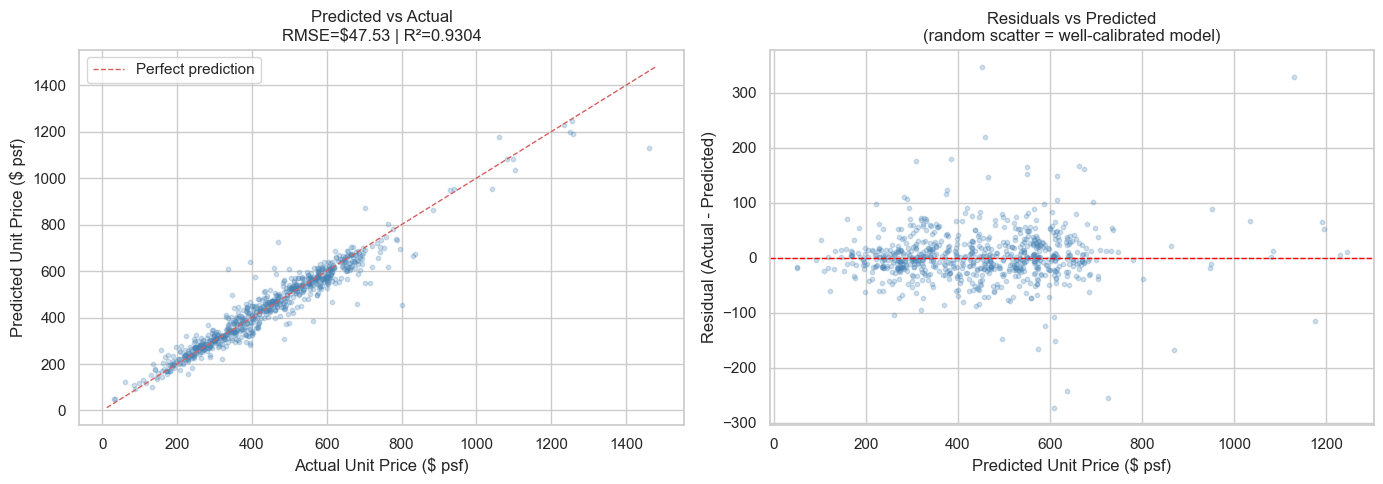

In [4]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig)

rmse_deploy, mae_deploy, r2_deploy = eval_metrics(y_test_raw, y_pred_xgb_no_macro)

# Predicted vs Actual
ax1 = fig.add_subplot(gs[0])
ax1.scatter(y_test_raw, y_pred_xgb_no_macro, alpha=0.25, s=10, color='steelblue')
lims = [min(y_test_raw.min(), y_pred_xgb_no_macro.min()) - 20,
        max(y_test_raw.max(), y_pred_xgb_no_macro.max()) + 20]
ax1.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax1.set_xlabel('Actual Unit Price ($ psf)')
ax1.set_ylabel('Predicted Unit Price ($ psf)')
ax1.set_title(f'Predicted vs Actual\nRMSE=${rmse_deploy:.2f} | R\u00b2={r2_deploy:.4f}')
ax1.legend()

# Residuals
residuals = y_test_raw.values - y_pred_xgb_no_macro
ax2 = fig.add_subplot(gs[1])
ax2.scatter(y_pred_xgb_no_macro, residuals, alpha=0.25, s=10, color='steelblue')
ax2.axhline(0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('Predicted Unit Price ($ psf)')
ax2.set_ylabel('Residual (Actual - Predicted)')
ax2.set_title('Residuals vs Predicted\n(random scatter = well-calibrated model)')

plt.tight_layout()
plt.show()

## 5. Feature Importance — Deployment Model

Feature Importances (gain-based) — No-Macro Model:
                    Feature  Importance
      Planning_Area_Encoded    0.228186
      Remaining_Lease_Years    0.194190
        Type of Sale_Resale    0.191411
              dist_to_mrt_m    0.092985
                   Log_Area    0.056316
Floor Level_Non-First Floor    0.052689
         Region_West Region    0.047092
         Region_East Region    0.045999
        Region_North Region    0.037102
        Floor Level_Unknown    0.019233
   Region_North-East Region    0.017448
      Lease_Remaining_Ratio    0.017348

Top 4 features account for 70.7% of importance


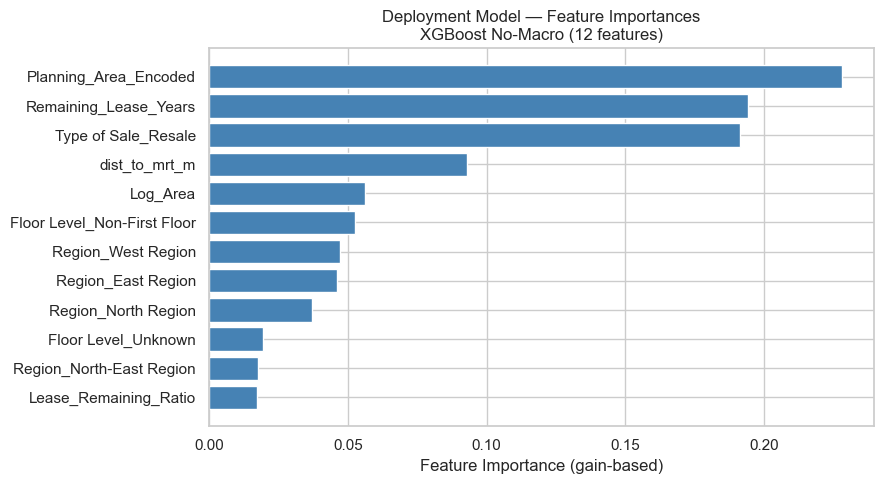

In [5]:
importances = xgb_no_macro.feature_importances_
feature_names = X_test_no_macro.columns.tolist()

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Feature Importances (gain-based) — No-Macro Model:')
print(importance_df.to_string(index=False))
print(f'\nTop 4 features account for {importance_df["Importance"][:4].sum()*100:.1f}% of importance')

fig, ax = plt.subplots(figsize=(9, 5))
sorted_df = importance_df.sort_values('Importance')
ax.barh(sorted_df['Feature'], sorted_df['Importance'], color='steelblue')
ax.set_xlabel('Feature Importance (gain-based)')
ax.set_title('Deployment Model — Feature Importances\nXGBoost No-Macro (12 features)')
plt.tight_layout()
plt.show()

## 6. Conclusion

### Model Selection

| Model | Features | Test RMSE | Test R² |
|---|---|---|---|
| Ridge Regression | 18 (scaled) | ~$88/psf | ~0.760 |
| Random Forest | 27 | ~$52/psf | ~0.916 |
| XGBoost — full | 27 | ~$49/psf | ~0.927 |
| XGBoost — reduced (retuned) | 16 | ~$47/psf | ~0.931 |
| **XGBoost — no macro (retuned)** | **12** | **~$48/psf** | **~0.930** |

### Deployment Decision

The best performing model by test RMSE is XGBoost reduced (16 features, $47.26/psf). However, the **no-macro model (12 features, $47.53/psf) is selected for deployment** based on the following reasoning:

| | XGBoost Reduced (16 features) | XGBoost No-Macro (12 features) |
|---|---|---|
| Test RMSE | $47.26/psf | $47.53/psf |
| Test R² | 0.9312 | 0.9304 |
| Performance difference | — | +$0.27/psf (within noise) |
| External data needed | GDP, CPI, SORA, Ready_Mixed_Concrete | None |
| Input at inference time | Property details + macro lookup | Property details only |
| Operational risk | Stale macro data silently degrades predictions | None |

The $0.27/psf RMSE difference is well within the CV standard deviation (~$3–4/psf) and is not statistically meaningful. The no-macro model is simpler, has no external data dependencies, and is more robust in production.

**Deployed model**: `xgboost_no_macro.pkl` — 12 features, retuned.

### Key Findings

1. **Tree-based models significantly outperform linear models** — R² 0.76 (Ridge) vs 0.930 (XGBoost). The relationship between property features and price is non-linear.

2. **Top price drivers** (gain-based importance): `Remaining_Lease_Years`, `Planning_Area_Encoded`, `Type of Sale_Resale`, `dist_to_mrt_m`. These four features account for ~70% of predictive power.

3. **Macro features are not necessary for production** — 15 macro/construction features collectively contribute marginal signal. Removing all of them costs only $0.27/psf in RMSE while eliminating 4 external data dependencies.

4. **Multicollinearity analysis (notebook 03) was empirically validated** — domain-knowledge-driven feature selection reduced the model from 27 to 16 features with a performance improvement, confirming the VIF-based grouping was analytically sound.

5. **Residuals are approximately randomly distributed** — no strong systematic bias, suggesting the model is well-calibrated across the price range.

### Limitations & Future Work

- **Practical error ceiling**: RMSE ~$48/psf (~10.6% of mean price) reflects irreducible noise in transactional data — negotiation, unit condition, and market timing are not captured.
- **Log transform overcorrection** (skew −0.845 after log): slight underestimation of upper price tail; Box-Cox transform is a candidate improvement for linear models.
- **Random Forest overfitting** (Train RMSE $22 vs CV RMSE $55): more aggressive regularisation (`min_samples_leaf > 5`) could close this gap.
- **Hyperparameter search scope**: `reg_alpha` and `reg_lambda` (XGBoost L1/L2 regularisation) were not tuned — further gains may be available.
- **Richer features**: floor plan quality, building age, proximity to expressways or industrial clusters could push performance beyond the current ceiling.